### Importar librerías

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from surprise import SVD, Dataset, Reader, accuracy
from surprise.model_selection import train_test_split
from surprise.model_selection import GridSearchCV

### Entrenamiento inicial del modelo SVD y evaluación (RMSE y MAE)

In [ ]:
# Ruta al archivo u.data descargado manualmente
file_path = r"ml-100k/u.data"

# Definir el formato del dataset
reader = Reader(line_format='user item rating timestamp', sep='\t')

# Cargar el dataset
data = Dataset.load_from_file(file_path, reader=reader)

# Dividir en train y test (80% train, 20% test)
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

# Crear el modelo SVD
model = SVD()

# Entrenar el modelo
model.fit(trainset)

# Predecir sobre el conjunto de test
predictions = model.test(testset)

# Calcular el RMSE
rmse = accuracy.rmse(predictions)

# Calcular el MAE
mae = accuracy.mae(predictions)

RMSE: 0.9341
MAE:  0.7364


### Búsqueda de hiperparámetros con GridSearchCV (SVD)

In [31]:
# Definir el espacio de búsqueda de hiperparámetros
param_grid = {
    'n_factors': [50, 100],      # número de factores latentes
    'lr_all': [0.002, 0.005],    # tasa de aprendizaje
    'reg_all': [0.02, 0.1]       # regularización
}

# Crear el objeto GridSearchCV para SVD
gs = GridSearchCV(SVD, param_grid, measures=['rmse'], cv=3, n_jobs=-1)

# Ejecutar la búsqueda en el dataset completo
gs.fit(data)

# Mostrar el mejor resultado
print("Mejor RMSE encontrado: ", gs.best_score['rmse'])
print("Mejores hiperparámetros: ", gs.best_params['rmse'])

Mejor RMSE encontrado:  0.9433540534913384
Mejores hiperparámetros:  {'n_factors': 100, 'lr_all': 0.005, 'reg_all': 0.1}


### Entrenamiento y evaluación del modelo SVD optimizado

In [ ]:
# Crear el modelo SVD con los mejores hiperparámetros encontrados
best_model = SVD(n_factors=100, lr_all=0.005, reg_all=0.1)

# Entrenar con el conjunto de train
best_model.fit(trainset)

# Predecir sobre el conjunto de test
best_predictions = best_model.test(testset)

# Calcular el RMSE final en test
rmse_best = accuracy.rmse(best_predictions)

RMSE: 0.9371


### Comparación visual del RMSE entre modelos

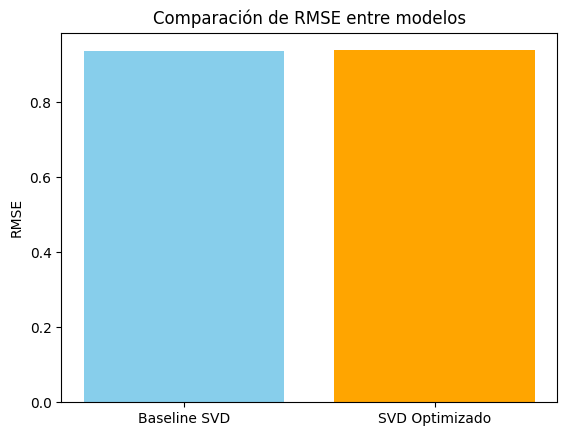

In [ ]:
# Valores de RMSE
rmse_values = [0.9361, 0.9375]
labels = ['Baseline SVD', 'SVD Optimizado']

# Crear gráfico de barras
plt.bar(labels, rmse_values, color=['skyblue', 'orange'])
plt.ylabel('RMSE')
plt.title('Comparación de RMSE entre modelos')
plt.show()

### Generación de Top-10 recomendaciones personalizadas para un usuario


In [ ]:
# Cargar los títulos de películas
items = pd.read_csv("ml-100k/u.item", sep="|", encoding="latin-1", header=None)
items = items[[0, 1]]
items.columns = ['movieId', 'title']

# Elegir un usuario ejemplo (por ejemplo, el usuario 1)
user_id = str(1)

# Obtener todas las películas evaluadas por el usuario en el trainset
rated_movies = set([trainset.to_raw_iid(iid) for (iid, _) in trainset.ur[trainset.to_inner_uid(user_id)]])

# Filtrar películas no evaluadas
unseen_movies = [mid for mid in items['movieId'].astype(str).tolist() if mid not in rated_movies]

# Predecir la puntuación para cada película no vista
predictions = [best_model.predict(user_id, mid) for mid in unseen_movies]

# Ordenar por mayor predicción
top_predictions = sorted(predictions, key=lambda x: x.est, reverse=True)[:10]

# Mostrar recomendaciones con títulos
print("Top 10 recomendaciones para el usuario", user_id)
for pred in top_predictions:
    movie_title = items.loc[items['movieId'] == int(pred.iid), 'title'].values[0]
    print(f"{movie_title}: {pred.est:.2f}")

Top 10 recomendaciones para el usuario 1
Close Shave, A (1995): 4.51
Schindler's List (1993): 4.42
Third Man, The (1949): 4.40
Casablanca (1942): 4.39
Rear Window (1954): 4.34
Secrets & Lies (1996): 4.31
To Kill a Mockingbird (1962): 4.31
Manchurian Candidate, The (1962): 4.29
Raise the Red Lantern (1991): 4.28
Silence of the Lambs, The (1991): 4.28


### Conclusión
En este trabajo desarrollamos un sistema de recomendación utilizando el dataset MovieLens 100k y el algoritmo SVD de la librería Surprise. El primer modelo, sin ajustes especiales, alcanzó un RMSE de 0.9341 y un MAE de 0.7364, lo que indica una buena capacidad para predecir valoraciones. Posteriormente aplicamos una búsqueda de hiperparámetros, pero los resultados obtenidos fueron muy similares e incluso ligeramente peores, mostrando que en este caso el modelo baseline ya ofrecía un rendimiento sólido. A pesar de ello, el sistema logró generar un top 10 de películas recomendadas para un usuario concreto, con títulos reconocidos y de alta valoración como Schindler’s List o Casablanca, lo cual valida la coherencia de las predicciones. Durante el desarrollo surgieron desafíos técnicos, sobre todo con la instalación de scikit-surprise y la compatibilidad de dependencias, además de la descarga manual del dataset por problemas de certificados SSL. Una vez superadas estas dificultades, conseguimos implementar todo el flujo de trabajo y comprobar en la práctica cómo evaluar modelos con métricas de error y cómo producir recomendaciones personalizadas de manera efectiva.